In [2]:
!pip install yfinance

     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------------- 949.2/949.2 kB 14.6 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 28.6 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.18.2-py3-none-any.whl size=139153 sha256=74c355f42d4b3aba6e8941583319521f6aea96824e3752c2c48f032aa2bf34a5
  Stored in directory: c:\users\jmfernandez\appdata\local\pip\cache\wheels\d1\df\a9\0202b051c65b11c992dd6db9f2babdd2c44ec7d35d511be5d3
Successfully built peewee


In [3]:
import sys
print(sys.executable)

C:\Users\jmfernandez\anaconda3\python.exe


In [10]:
import yfinance as yf

In [11]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [71]:
import pandas as pd
import requests
from io import StringIO

In [72]:
# Step 1: Fetch the page with headers
headers = {
    "User-Agent": "Mozilla/5.0"
}
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
response = requests.get(url, headers=headers)
html_data = response.text

In [73]:
# ✅ Step 2: Wrap the HTML in StringIO to satisfy read_html
tables = pd.read_html(StringIO(html_data))

# Step 3: Preview results
print(f"✅ Found {len(tables)} tables")
for i, table in enumerate(tables):
    print(f"\n--- Table {i} ---\n", table.head())

✅ Found 6 tables

--- Table 0 ---
    Tesla Annual Revenue (Millions of US $)  \
0                                     2024   
1                                     2023   
2                                     2022   
3                                     2021   
4                                     2020   

  Tesla Annual Revenue (Millions of US $).1  
0                                   $97,690  
1                                   $96,773  
2                                   $81,462  
3                                   $53,823  
4                                   $31,536  

--- Table 1 ---
   Tesla Quarterly Revenue (Millions of US $)  \
0                                 2025-03-31   
1                                 2024-12-31   
2                                 2024-09-30   
3                                 2024-06-30   
4                                 2024-03-31   

  Tesla Quarterly Revenue (Millions of US $).1  
0                                      $19,335  
1      

In [85]:
# Step 3: Preview results
print(f"✅ Found {len(tables)} tables")
for i, table in enumerate(tables):
    print(f"\n--- Table {i} ---\n", table.head())

✅ Found 6 tables

--- Table 0 ---
    Tesla Annual Revenue (Millions of US $)  \
0                                     2024   
1                                     2023   
2                                     2022   
3                                     2021   
4                                     2020   

  Tesla Annual Revenue (Millions of US $).1  
0                                   $97,690  
1                                   $96,773  
2                                   $81,462  
3                                   $53,823  
4                                   $31,536  

--- Table 1 ---
   Tesla Quarterly Revenue (Millions of US $)  \
0                                 2025-03-31   
1                                 2024-12-31   
2                                 2024-09-30   
3                                 2024-06-30   
4                                 2024-03-31   

  Tesla Quarterly Revenue (Millions of US $).1  
0                                      $19,335  
1      

In [86]:
GameStop = yf.Ticker("GME")

In [87]:
gme_data = GameStop.history(period="max")

In [88]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [89]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

html_data  = requests.get(url).text

In [91]:
soup = BeautifulSoup(html_data, "html.parser")

In [93]:
gme_data = []

for table in soup.find_all('table'):
    if table.find('th') and 'GameStop Quarterly Revenue' in table.find('th').text:
        rows = table.find_all('tr')
        
        for row in rows:
            col = row.find_all('td')
            if col:
                date = col[0].text.strip()
                revenue = col[1].text.strip().replace(',', '').replace('$', '')
                
                gme_data.append({"Date": date, "Revenue": revenue})

# Convert to DataFrame after the loop
gme_revenue = pd.DataFrame(gme_data)gme_revenue.tail()

In [94]:
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


In [98]:
import matplotlib.pyplot as plt

In [99]:
def make_graph(data, title):
    plt.figure(figsize=(10, 5))
    plt.plot(data['Date'], data['Close'], marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [100]:
tesla_data = pd.DataFrame({
    'Date': ['2024-01-01', '2024-02-01', '2024-03-01'],
    'Close': [200, 210, 195]
})
tesla_data['Date'] = pd.to_datetime(tesla_data['Date'])

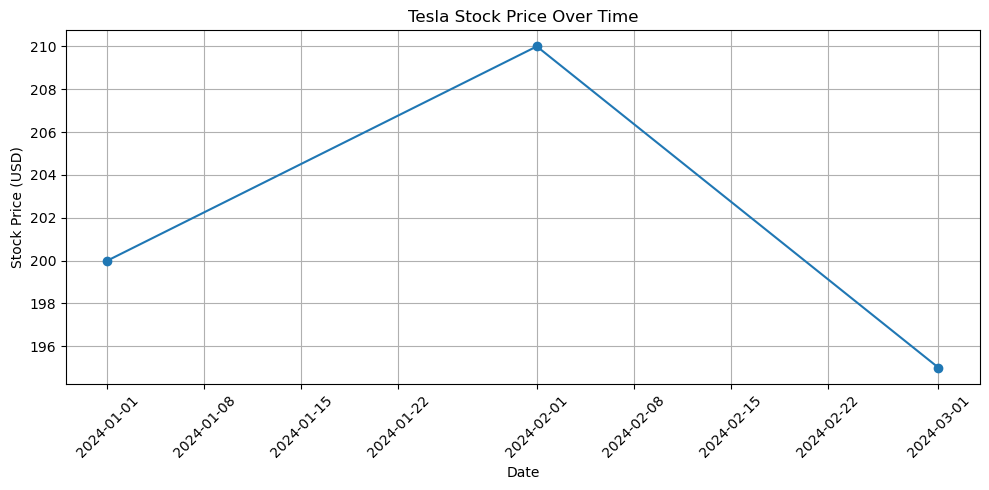

In [101]:
make_graph(tesla_data, "Tesla Stock Price Over Time")

In [102]:
import matplotlib.pyplot as plt

def make_graph(data, title):
    plt.figure(figsize=(10, 5))
    plt.plot(data['Date'], data['Close'], marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [103]:
gme_data = pd.DataFrame({
    'Date': ['2024-01-01', '2024-02-01', '2024-03-01'],
    'Close': [22.5, 24.3, 23.1]
})
gme_data['Date'] = pd.to_datetime(gme_data['Date'])

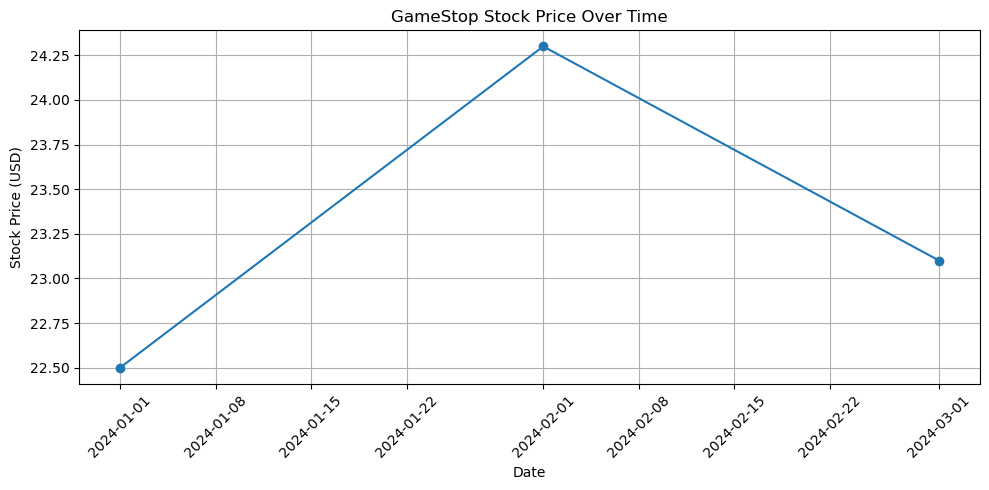

In [104]:
make_graph(gme_data, "GameStop Stock Price Over Time")